# 분위수 회귀 (Quantile Regression)

---

## 분석 목적

주식 시장 극단 하락 구간(τ ≤ 0.10)에서 BTC가 반대로 움직이는지 검증 → Safe Haven 여부 판별  
자세한 방법론은 [README.md](README.md) 참조.

### 참조 논문

- Koenker & Bassett (1978) — 분위수 회귀 원조
- Newey & West (1987, 1994) — HAC 표준오차
- Baur & Lucey (2010) — Safe-Haven 판정 기준

---
## Step 0. 라이브러리

In [1]:
!pip install pandas numpy matplotlib scipy statsmodels --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.regression.quantile_regression import QuantReg
from scipy import stats
import warnings, os, platform
warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_war': '2022-02-24',
    'israel_hamas_war'           : '2023-10-07',
    'israel_iran'            : '2024-04-01',
    'us_israel_iran'         : '2026-02-28',
}
EVENT_LABELS = {
    'hormuz_crisis'          : '호르무즈 위기',
    'soleimani_assassination': '솔레이마니 암살',
    'russia_ukraine_war': '러-우 전쟁',
    'israel_hamas_war'           : '이스라엘-하마스',
    'israel_iran'            : '이스라엘-이란 충돌',
    'us_israel_iran'         : '이란 전쟁',
}

# 분석할 분위수 - 분쉬수 0.01, 0.05, 0.20 추가
TAUS = [0.01, 0.025, 0.05, 0.10, 0.20, 0.25, 0.50, 0.75, 0.90, 0.95]
# Safe-Haven 판단 핵심 분위수
CORE_TAUS = [0.05, 0.10, 0.50]

print('✅ 환경 설정 완료')
print(f'   분석 분위수: {TAUS}')

# ── 결과 출력 디렉토리 (표준화) ──
RESULTS_DIR = 'result_csv_png'  # 노트북 기준 상대경로
os.makedirs(RESULTS_DIR, exist_ok=True)


✅ 환경 설정 완료
   분석 분위수: [0.01, 0.025, 0.05, 0.1, 0.2, 0.25, 0.5, 0.75, 0.9, 0.95]


---
## Step 1. master_data.csv 로드

In [3]:
if not os.path.exists('../master_data/result_csv_png/master_data.csv'):
    raise FileNotFoundError('../master_data/result_csv_png/master_data.csv 없음')

master = pd.read_csv('../master_data/result_csv_png/master_data.csv')
master['date'] = pd.to_datetime(master['date'])

for col in ['BTC','Gold','TLT','DXY','SP500','NASDAQ',
            'GPR_custom','VIX','fear_greed_lag1']:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

print(f'✅ master_data: {len(master)}행')
print(f'   기간: {master["date"].min().date()} ~ {master["date"].max().date()}')
print(f'\n이벤트별 거래일:')
print(master.groupby('event_name')['date'].count().to_string())
print(f'\n결측치:')
key_cols = ['BTC','SP500','GPR_custom']
print(master[key_cols].isnull().sum().to_string())

✅ master_data: 1827행
   기간: 2019-01-02 ~ 2026-04-30

이벤트별 거래일:
event_name
hormuz_crisis              182
israel_hamas_war           260
israel_iran                299
russia_ukraine_war         475
soleimani_assassination    339
us_israel_iran             272

결측치:
BTC           0
SP500         0
GPR_custom    0


---
## Step 2. 분석 데이터 준비

**전처리**: 결측치 제거(BTC·SP500·GPR_custom·Gold 동시 존재 행) → Z-score 표준화(`_z` 컬럼 생성)

In [4]:
key_cols = ['BTC', 'SP500', 'GPR_custom', 'Gold']
data_all = master.dropna(subset=key_cols).copy()

# Z-score 표준화 (전체 기준) - Gold 추가
for col in ['SP500', 'GPR_custom', 'VIX', 'Gold']:
    if col in data_all.columns:
        mu, sig = data_all[col].mean(), data_all[col].std()
        if sig > 0:
            data_all[f'{col}_z'] = (data_all[col] - mu) / sig
        else:
            data_all[f'{col}_z'] = 0

print(f'전체 분석 데이터: {len(data_all)}행')

# 주요 자산별 수익률 분위수 확인
assets = ['BTC', 'SP500', 'Gold']

for asset in assets:
    print(f'\n{asset} 수익률 분위수:')
    print(data_all[asset].quantile(TAUS).round(4))

for asset in assets:
    print(f'\n{asset} 수익률 분위수 (% 버전):')
    print((data_all[asset] * 100).quantile(TAUS).round(4))

전체 분석 데이터: 1827행

BTC 수익률 분위수:
0.010   -0.1092
0.025   -0.0737
0.050   -0.0570
0.100   -0.0367
0.200   -0.0208
0.250   -0.0160
0.500    0.0009
0.750    0.0197
0.900    0.0437
0.950    0.0636
Name: BTC, dtype: float64

SP500 수익률 분위수:
0.010   -0.0350
0.025   -0.0253
0.050   -0.0177
0.100   -0.0119
0.200   -0.0063
0.250   -0.0044
0.500    0.0010
0.750    0.0067
0.900    0.0122
0.950    0.0165
Name: SP500, dtype: float64

Gold 수익률 분위수:
0.010   -0.0295
0.025   -0.0233
0.050   -0.0172
0.100   -0.0117
0.200   -0.0059
0.250   -0.0043
0.500    0.0010
0.750    0.0065
0.900    0.0126
0.950    0.0173
Name: Gold, dtype: float64

BTC 수익률 분위수 (% 버전):
0.010   -10.9194
0.025    -7.3733
0.050    -5.6969
0.100    -3.6690
0.200    -2.0833
0.250    -1.5995
0.500     0.0920
0.750     1.9677
0.900     4.3707
0.950     6.3640
Name: BTC, dtype: float64

SP500 수익률 분위수 (% 버전):
0.010   -3.5036
0.025   -2.5266
0.050   -1.7704
0.100   -1.1934
0.200   -0.6324
0.250   -0.4420
0.500    0.0969
0.750    0.6693
0.900    

---
## Step 3. 분위수 회귀 — 전체 이벤트 합산

기본 모델: `Q_τ(BTC) = α + β·Asset_z + γ·GPR_z + ε`  
HAC(Newey-West) 표준오차 + 블록 부트스트랩 적용

**Safe-Haven 판정 기준 (Baur & Lucey 2010)**

| 조건 | 판정 |
|---|---|
| β < 0, p < 0.05 (τ ≤ 0.10) | ✅ Safe Haven |
| β > 0, p < 0.05 (τ ≤ 0.10) | ❌ Risky Asset |
| p ≥ 0.05 | ⚪ 비유의 |

In [5]:
import numpy as np
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.tools import add_constant
from scipy.stats import t as t_dist

# ══════════════════════════════════════════════════════
# 모델 정의
# ══════════════════════════════════════════════════════
MODELS = {
    'SP500+GPR': ['SP500_z', 'GPR_custom_z'],  # 주식 + 전쟁지수
    'Gold+GPR' : ['Gold_z',  'GPR_custom_z'],  # 금   + 전쟁지수
}

# ══════════════════════════════════════════════════════
# HAC 함수 (x_cols를 외부에서 받도록 수정)
# ══════════════════════════════════════════════════════
def run_quantreg_hac(data, tau, y_col='BTC', x_cols=None, min_n=30):
    if x_cols is None:
        x_cols = ['SP500_z', 'GPR_custom_z']

    available_x = [c for c in x_cols if c in data.columns]
    df = data[[y_col] + available_x].dropna()
    if len(df) < min_n:
        return None

    effective_n = len(df) * tau
    if effective_n < 5:
        print(f"  ⚠️  τ={tau} 유효 데이터 {effective_n:.1f}개")

    y = df[y_col].values
    X = add_constant(df[available_x].values)
    n = len(df)
    bw = max(1, int(4 * (n / 100) ** (2/9)))

    try:
        model  = QuantReg(y, X)
        res    = model.fit(q=tau, max_iter=2000, p_tol=1e-05, vcov='iid')
        params = res.params
        resid  = y - X @ params
        n, k   = X.shape

        S       = np.zeros((k, k))
        Gamma_0 = (resid[:, None] * X).T @ (resid[:, None] * X) / n
        S      += Gamma_0

        for lag in range(1, bw + 1):
            weight  = 1 - lag / (bw + 1)
            Gamma_l = (resid[lag:, None] * X[lag:]).T \
                    @ (resid[:-lag, None] * X[:-lag]) / n
            S += weight * (Gamma_l + Gamma_l.T)

        XX_inv = np.linalg.inv(X.T @ X / n)
        V_hac  = XX_inv @ S @ XX_inv / n
        se_hac = np.sqrt(np.diag(V_hac))
        t_stat = params / se_hac
        pvals  = 2 * (1 - t_dist.cdf(np.abs(t_stat), df=n - k))

        return {
            'tau'     : tau,
            'n'       : n,
            'eff_n'   : effective_n,
            'bw'      : bw,
            'params'  : params,
            'se'      : se_hac,
            'pvalues' : pvals,
            'conf_int': np.column_stack([params - 1.96 * se_hac,
                                         params + 1.96 * se_hac]),
            'x_cols'  : ['const'] + available_x,
            'result'  : res,
            'method'  : f'HAC(bw={bw})',
        }
    except Exception as e:
        print(f'  ⚠️ τ={tau} HAC 오류: {e}')
        return None


# ══════════════════════════════════════════════════════
# Safe-Haven 판정
# ══════════════════════════════════════════════════════
def judge_safe_haven(b, pb, b_median, tau):
    if tau > 0.10:
        return '—'
    if pd.isna(pb) or pd.isna(b):
        return '⚪ 판정불가'
    if pb < 0.05 and b < 0:
        if b_median is not None and b < b_median:
            return '✅ Safe Haven(위기 강화)'
        elif b_median is not None and b >= b_median:
            return '⚠️ 항상 반대자산 의심'
        return '✅ Safe Haven'
    elif pb < 0.05 and b > 0:
        return '❌ Risky Asset'
    elif pb < 0.10 and b < 0:
        return '🔵 Weak SH(10%)'
    return '⚪ 비유의'


# ══════════════════════════════════════════════════════
# 단일 데이터셋 × 두 모델 출력 함수
# ══════════════════════════════════════════════════════
def run_and_print_both_models(data, label='전체 합산'):
    """
    SP500+GPR / Gold+GPR 두 모델을 나란히 출력
    """
    print(f'\n{"═"*90}')
    print(f'  📌 {label}')
    print(f'{"═"*90}')

    # 결과 저장
    model_results = {}

    for model_name, x_cols in MODELS.items():

        print(f'\n  ── {model_name} ──────────────────────────────────────')

        # 주요 변수명 (SP500_z or Gold_z)
        main_var = x_cols[0]

        # τ=0.50 중앙값 β 사전 계산
        res_med     = run_quantreg_hac(data, 0.50, x_cols=x_cols)
        b_median    = None
        if res_med and main_var in res_med['x_cols']:
            idx      = res_med['x_cols'].index(main_var)
            b_median = res_med['params'][idx]

        print(f'  {"τ":>6} {"n":>5} {"유효n":>6} {"BW":>4} '
              f'{f"β({main_var})":>14} {"p(β)":>8} '
              f'{"γ(GPR)":>12} {"p(γ)":>8}  {"판정"}')
        print('  ' + '-' * 88)

        tau_results = {}

        for tau in TAUS:
            res = run_quantreg_hac(data, tau, x_cols=x_cols)
            tau_results[tau] = res

            if res is None:
                print(f'  {tau:>6.2f}  데이터 부족')
                continue

            x_c   = res['x_cols']
            m_i   = x_c.index(main_var)          if main_var      in x_c else None
            gpr_i = x_c.index('GPR_custom_z')    if 'GPR_custom_z' in x_c else None

            b   = res['params'][m_i]   if m_i   is not None else np.nan
            pb  = res['pvalues'][m_i]  if m_i   is not None else np.nan
            g   = res['params'][gpr_i] if gpr_i is not None else np.nan
            pg  = res['pvalues'][gpr_i] if gpr_i is not None else np.nan

            sig_b = '✅' if pb < 0.05 else '△' if pb < 0.10 else '—'
            sig_g = '✅' if pg < 0.05 else '△' if pg < 0.10 else '—'

            verdict = judge_safe_haven(
                b, pb,
                b_median if tau <= 0.10 else None,
                tau
            )

            print(f'  {tau:>6.2f} {res["n"]:>5} {res["eff_n"]:>6.1f} '
                  f'{res["bw"]:>4} '
                  f'{b:>12.5f}{sig_b:>2} {pb:>8.4f} '
                  f'{g:>10.5f}{sig_g:>2} {pg:>8.4f}  {verdict}')

        model_results[model_name] = tau_results

    # ── 두 모델 핵심 비교 요약 ──────────────────────────────
    print(f'\n  {"─"*88}')
    print(f'  ▶ [{label}] 핵심 비교 — τ=0.05, 0.10')
    print(f'  {"─"*88}')
    print(f'  {"모델":<14} {"τ":>6} '
          f'{"β":>12} {"p":>8} {"판정"}')
    print(f'  {"─"*55}')

    for model_name, x_cols in MODELS.items():
        main_var = x_cols[0]
        for tau in [0.05, 0.10]:
            res = model_results[model_name].get(tau)
            if res is None:
                print(f'  {model_name:<14} {tau:>6.2f}  데이터 부족')
                continue
            x_c = res['x_cols']
            m_i = x_c.index(main_var) if main_var in x_c else None
            if m_i is None:
                continue
            b  = res['params'][m_i]
            pb = res['pvalues'][m_i]

            res_med  = model_results[model_name].get(0.50)
            b_med    = None
            if res_med and main_var in res_med['x_cols']:
                b_med = res_med['params'][res_med['x_cols'].index(main_var)]

            verdict = judge_safe_haven(b, pb, b_med, tau)
            sig = '✅' if pb < 0.05 else '△' if pb < 0.10 else '—'
            print(f'  {model_name:<14} {tau:>6.2f} '
                  f'{b:>12.5f}{sig:>2} {pb:>8.4f}  {verdict}')
        print()

    return model_results


# ══════════════════════════════════════════════════════
# Step 3. 전체 합산 실행
# ══════════════════════════════════════════════════════

# 다중공선성 사전 확인
print('▶ 다중공선성 사전 확인')
for model_name, x_cols in MODELS.items():
    existing = [c for c in x_cols if c in data_all.columns]
    if len(existing) >= 2:
        corr = data_all[existing].corr().iloc[0, 1]
        flag = '⚠️ 위험' if abs(corr) > 0.5 else '✅ 이상없음'
        print(f'  [{model_name}] {existing[0]} ↔ {existing[1]}: '
              f'{corr:.3f}  {flag}')

results_all = run_and_print_both_models(data_all, label='전체 합산')


# ══════════════════════════════════════════════════════
# Step 4. 이벤트별 실행
# ══════════════════════════════════════════════════════
results_event = {}

for event, event_label in EVENT_LABELS.items():
    sub   = data_all[data_all['event_name'] == event].copy()
    n_sub = len(sub.dropna(subset=['BTC', 'SP500_z', 'Gold_z', 'GPR_custom_z']))

    if n_sub < 30:
        print(f'\n⚠️  {event_label}: n={n_sub} < 30 → 분석 불가')
        results_event[event] = None
        continue

    results_event[event] = run_and_print_both_models(sub, label=event_label)


# ══════════════════════════════════════════════════════
# 최종 비교표 — 전쟁별 × 모델별
# ══════════════════════════════════════════════════════
print('\n\n' + '═' * 95)
print('  📊 최종 비교표 — 전쟁별 × SP500+GPR / Gold+GPR')
print('═' * 95)
print(f'  {"이벤트":<22} {"n":>5} '
      f'{"SP500 τ=0.05":>14} {"p":>7} '
      f'{"Gold τ=0.05":>13} {"p":>7}  '
      f'{"SP500판정":<22} {"Gold판정"}')
print('  ' + '-' * 100)

for event, event_label in EVENT_LABELS.items():
    ev_res = results_event.get(event)
    n_ev   = len(data_all[data_all['event_name'] == event]
                 .dropna(subset=['BTC', 'SP500_z', 'Gold_z', 'GPR_custom_z']))

    if ev_res is None:
        print(f'  {event_label:<22} {n_ev:>5}  분석 불가')
        continue

    row = {}
    for model_name, x_cols in MODELS.items():
        main_var = x_cols[0]
        res_05   = ev_res.get(model_name, {}).get(0.05)
        res_50   = ev_res.get(model_name, {}).get(0.50)

        if res_05 is None:
            row[model_name] = (np.nan, np.nan, 'N/A')
            continue

        x_c = res_05['x_cols']
        m_i = x_c.index(main_var) if main_var in x_c else None
        if m_i is None:
            row[model_name] = (np.nan, np.nan, 'N/A')
            continue

        b  = res_05['params'][m_i]
        pb = res_05['pvalues'][m_i]

        b_med = None
        if res_50 and main_var in res_50['x_cols']:
            b_med = res_50['params'][res_50['x_cols'].index(main_var)]

        verdict = judge_safe_haven(b, pb, b_med, 0.05)
        row[model_name] = (b, pb, verdict)

    b_sp, p_sp, v_sp = row.get('SP500+GPR', (np.nan, np.nan, 'N/A'))
    b_gd, p_gd, v_gd = row.get('Gold+GPR',  (np.nan, np.nan, 'N/A'))

    b_sp_s = f'{b_sp:.5f}' if pd.notna(b_sp) else '   N/A  '
    p_sp_s = f'{p_sp:.4f}' if pd.notna(p_sp) else '  N/A '
    b_gd_s = f'{b_gd:.5f}' if pd.notna(b_gd) else '   N/A  '
    p_gd_s = f'{p_gd:.4f}' if pd.notna(p_gd) else '  N/A '

    print(f'  {event_label:<22} {n_ev:>5} '
          f'{b_sp_s:>14} {p_sp_s:>7} '
          f'{b_gd_s:>13} {p_gd_s:>7}  '
          f'{v_sp:<22} {v_gd}')

print('\n  ✅=안전자산  🔵=약한경향  ❌=위험자산  ⚪=비유의  ⚠️=항상반대')

▶ 다중공선성 사전 확인
  [SP500+GPR] SP500_z ↔ GPR_custom_z: -0.031  ✅ 이상없음
  [Gold+GPR] Gold_z ↔ GPR_custom_z: 0.013  ✅ 이상없음

══════════════════════════════════════════════════════════════════════════════════════════
  📌 전체 합산
══════════════════════════════════════════════════════════════════════════════════════════

  ── SP500+GPR ──────────────────────────────────────
       τ     n    유효n   BW     β(SP500_z)     p(β)       γ(GPR)     p(γ)  판정
  ----------------------------------------------------------------------------------------
    0.01  1827   18.3    7      0.02552 ✅   0.0000   -0.00036 —   0.9555  ❌ Risky Asset
    0.03  1827   45.7    7      0.02099 ✅   0.0000    0.00089 —   0.8432  ❌ Risky Asset
    0.05  1827   91.4    7      0.01786 ✅   0.0000    0.00138 —   0.6791  ❌ Risky Asset
    0.10  1827  182.7    7      0.01585 ✅   0.0000    0.00061 —   0.8103  ❌ Risky Asset
    0.20  1827  365.4    7      0.01303 ✅   0.0000    0.00080 —   0.6347  —
    0.25  1827  456.8    7      0.01212

**이벤트 합산 결론**: 전 위기 분위수(τ=0.01~0.10)에서 β > 0 (SP500·Gold 모두) → ❌ Risky Asset

---
## Step 4. 상호작용항 모델

`Q_τ(BTC) = α + β·Asset_z + γ·GPR_z + δ·(Asset_z × GPR_z) + ε`  
δ < 0 → GPR↑ 시 동조화 약화(Safe Haven 강화), δ > 0 → 동조화 강화

| δ 부호 | p값 | 의미 |
|---|---|---|
| δ < 0 | < 0.05 | GPR↑ → Safe Haven 강화 |
| δ > 0 | < 0.05 | GPR↑ → 위험자산 동조화 강화 |
| — | ≥ 0.05 | 비유의 |

In [6]:
import numpy as np
import pandas as pd
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.tools import add_constant
from scipy.stats import t as t_dist

# ══════════════════════════════════════════════════════
# 모델 정의 — 상호작용항 포함
# ══════════════════════════════════════════════════════
# 상호작용항은 함수 내부에서 자동 생성
# SP500×GPR, Gold×GPR 각각
MODELS = {
    'SP500+GPR+IA': {
        'main'  : 'SP500_z',
        'gpr'   : 'GPR_custom_z',
        'ia_col': 'SP500_x_GPR',   # 상호작용항 컬럼명
        'label' : 'SP500×GPR 상호작용',
    },
    'Gold+GPR+IA': {
        'main'  : 'Gold_z',
        'gpr'   : 'GPR_custom_z',
        'ia_col': 'Gold_x_GPR',
        'label' : 'Gold×GPR 상호작용',
    },
}


# ══════════════════════════════════════════════════════
# 상호작용항 생성 함수
# ══════════════════════════════════════════════════════
def add_interaction(data, model_cfg):
    """
    SP500_z × GPR_custom_z 또는 Gold_z × GPR_custom_z 컬럼 생성
    원본 데이터를 복사 후 반환
    """
    df = data.copy()
    main  = model_cfg['main']
    gpr   = model_cfg['gpr']
    ia    = model_cfg['ia_col']

    if main in df.columns and gpr in df.columns:
        df[ia] = df[main] * df[gpr]
    else:
        print(f'  ⚠️  상호작용항 생성 실패: {main} 또는 {gpr} 없음')

    return df


# ══════════════════════════════════════════════════════
# HAC (Newey-West) — 상호작용항 포함
# ══════════════════════════════════════════════════════
def run_quantreg_hac_ia(data, tau, model_cfg,
                         y_col='BTC', min_n=30):
    """
    상호작용항 포함 분위수 회귀 (HAC SE)

    모델:
    Q_τ(BTC) = α + β·Main + γ·GPR + δ·(Main×GPR) + ε

    δ 해석:
    - δ < 0: GPR 높을수록 Main의 BTC 영향이 감소
             → 전쟁 위기 시 주식/금 연동이 약해짐 = Safe Haven 강화
    - δ > 0: GPR 높을수록 Main의 BTC 영향이 증가
             → 전쟁 위기 시 동조화 강화 = 위험자산 성격
    """
    main  = model_cfg['main']
    gpr   = model_cfg['gpr']
    ia    = model_cfg['ia_col']

    # 상호작용항 생성
    df_ia = add_interaction(data, model_cfg)

    x_cols = [main, gpr, ia]
    available_x = [c for c in x_cols if c in df_ia.columns]

    df = df_ia[[y_col] + available_x].dropna()
    if len(df) < min_n:
        return None

    effective_n = len(df) * tau
    if effective_n < 5:
        print(f"  ⚠️  τ={tau} 유효 데이터 {effective_n:.1f}개")

    y = df[y_col].values
    X = add_constant(df[available_x].values)
    n = len(df)
    bw = max(1, int(4 * (n / 100) ** (2/9)))

    try:
        model  = QuantReg(y, X)
        res    = model.fit(q=tau, max_iter=2000, p_tol=1e-05, vcov='iid')
        params = res.params
        resid  = y - X @ params
        n, k   = X.shape

        # Newey-West HAC
        S       = np.zeros((k, k))
        Gamma_0 = (resid[:, None] * X).T @ (resid[:, None] * X) / n
        S      += Gamma_0

        for lag in range(1, bw + 1):
            weight  = 1 - lag / (bw + 1)
            Gamma_l = (resid[lag:, None] * X[lag:]).T \
                    @ (resid[:-lag, None] * X[:-lag]) / n
            S += weight * (Gamma_l + Gamma_l.T)

        XX_inv = np.linalg.inv(X.T @ X / n)
        V_hac  = XX_inv @ S @ XX_inv / n
        se_hac = np.sqrt(np.diag(V_hac))
        t_stat = params / se_hac
        pvals  = 2 * (1 - t_dist.cdf(np.abs(t_stat), df=n - k))

        x_cols_full = ['const'] + available_x

        return {
            'tau'     : tau,
            'n'       : n,
            'eff_n'   : effective_n,
            'bw'      : bw,
            'params'  : params,
            'se'      : se_hac,
            'pvalues' : pvals,
            'conf_int': np.column_stack([params - 1.96 * se_hac,
                                         params + 1.96 * se_hac]),
            'x_cols'  : x_cols_full,
            'result'  : res,
            'method'  : f'HAC+IA(bw={bw})',
        }
    except Exception as e:
        print(f'  ⚠️ τ={tau} HAC+IA 오류: {e}')
        return None


# ══════════════════════════════════════════════════════
# Safe-Haven 판정 — 상호작용항(δ) 반영
# ══════════════════════════════════════════════════════
def judge_safe_haven_ia(b, pb, delta, pd_delta, b_median, tau):
    """
    상호작용항을 반영한 Safe-Haven 판정

    조건 계층:
    1순위: β < 0 & p < 0.05  (주식/금 폭락 시 BTC 반대)
    2순위: δ < 0 & p < 0.05  (전쟁 강도 높을수록 Safe Haven 강화)
    둘 다 충족 → 강한 Safe Haven
    """
    if tau > 0.10:
        return '—'
    if pd.isna(pb) or pd.isna(b):
        return '⚪ 판정불가'

    beta_sh    = pb    < 0.05 and b     < 0
    beta_risky = pb    < 0.05 and b     > 0
    delta_sh   = pd.notna(pd_delta) and pd_delta < 0.05 and delta < 0
    delta_risk = pd.notna(pd_delta) and pd_delta < 0.05 and delta > 0

    if beta_sh and delta_sh:
        return '✅✅ 강한 Safe Haven'
    elif beta_sh and not delta_risk:
        if b_median is not None and b < b_median:
            return '✅ Safe Haven(위기강화)'
        return '✅ Safe Haven'
    elif not beta_sh and delta_sh:
        return '🔵 δ만 유의(상호작용 Safe Haven)'
    elif beta_risky:
        return '❌ Risky Asset'
    elif pb < 0.10 and b < 0:
        return '🔵 Weak SH(10%)'
    return '⚪ 비유의'


# ══════════════════════════════════════════════════════
# 단일 데이터셋 × 두 모델 출력
# ══════════════════════════════════════════════════════
def run_and_print_ia(data, label='전체 합산'):
    """
    SP500+GPR+IA / Gold+GPR+IA 두 모델 나란히 출력
    """
    print(f'\n{"═"*95}')
    print(f'  📌 {label}')
    print(f'{"═"*95}')

    model_results = {}

    for model_name, cfg in MODELS.items():
        main_var = cfg['main']
        ia_col   = cfg['ia_col']

        print(f'\n  ── {model_name} ({cfg["label"]}) ──────────────────')
        print(f'  모델: BTC = α + β·{main_var} + γ·GPR + δ·({main_var}×GPR)')
        print(f'  δ<0&유의 → 전쟁 강도 높을수록 Safe Haven 강화\n')

        # τ=0.50 중앙값 β 사전 계산
        res_med  = run_quantreg_hac_ia(data, 0.50, cfg)
        b_median = None
        if res_med and main_var in res_med['x_cols']:
            idx      = res_med['x_cols'].index(main_var)
            b_median = res_med['params'][idx]

        # 헤더
        print(f'  {"τ":>6} {"n":>5} {"유효n":>6} {"BW":>4} '
              f'{f"β({main_var})":>14} {"p(β)":>8} '
              f'{"γ(GPR)":>10} {"p(γ)":>7} '
              f'{"δ(IA)":>10} {"p(δ)":>7}  {"판정"}')
        print('  ' + '-' * 105)

        tau_results = {}

        for tau in TAUS:
            res = run_quantreg_hac_ia(data, tau, cfg)
            tau_results[tau] = res

            if res is None:
                print(f'  {tau:>6.2f}  데이터 부족')
                continue

            x_c   = res['x_cols']
            m_i   = x_c.index(main_var) if main_var in x_c else None
            gpr_i = x_c.index(cfg['gpr']) if cfg['gpr'] in x_c else None
            ia_i  = x_c.index(ia_col)    if ia_col   in x_c else None

            b     = res['params'][m_i]   if m_i   is not None else np.nan
            pb    = res['pvalues'][m_i]  if m_i   is not None else np.nan
            g     = res['params'][gpr_i] if gpr_i is not None else np.nan
            pg    = res['pvalues'][gpr_i] if gpr_i is not None else np.nan
            delta = res['params'][ia_i]  if ia_i  is not None else np.nan
            pd_d  = res['pvalues'][ia_i] if ia_i  is not None else np.nan

            sig_b = '✅' if pb  < 0.05 else '△' if pb  < 0.10 else '—'
            sig_g = '✅' if pg  < 0.05 else '△' if pg  < 0.10 else '—'
            sig_d = '✅' if pd.notna(pd_d) and pd_d < 0.05 else \
                    '△'  if pd.notna(pd_d) and pd_d < 0.10 else '—'

            verdict = judge_safe_haven_ia(
                b, pb, delta, pd_d,
                b_median if tau <= 0.10 else None,
                tau
            )

            print(f'  {tau:>6.2f} {res["n"]:>5} {res["eff_n"]:>6.1f} '
                  f'{res["bw"]:>4} '
                  f'{b:>12.5f}{sig_b:>2} {pb:>8.4f} '
                  f'{g:>8.5f}{sig_g:>2} {pg:>7.4f} '
                  f'{delta:>8.5f}{sig_d:>2} {pd_d:>7.4f}  {verdict}')

        model_results[model_name] = tau_results

    # ── 핵심 비교 요약 (τ=0.05, 0.10) ──────────────────────
    print(f'\n  {"─"*95}')
    print(f'  ▶ [{label}] 핵심 비교 — τ=0.05 / 0.10')
    print(f'  {"─"*95}')
    print(f'  {"모델":<18} {"τ":>6} '
          f'{"β":>12} {"p(β)":>8} '
          f'{"δ(IA)":>10} {"p(δ)":>8}  {"판정"}')
    print(f'  {"─"*75}')

    for model_name, cfg in MODELS.items():
        main_var = cfg['main']
        ia_col   = cfg['ia_col']

        for tau in [0.05, 0.10]:
            res    = model_results[model_name].get(tau)
            res_50 = model_results[model_name].get(0.50)
            if res is None:
                print(f'  {model_name:<18} {tau:>6.2f}  데이터 부족')
                continue

            x_c   = res['x_cols']
            m_i   = x_c.index(main_var) if main_var in x_c else None
            ia_i  = x_c.index(ia_col)   if ia_col   in x_c else None

            b     = res['params'][m_i]  if m_i  is not None else np.nan
            pb    = res['pvalues'][m_i] if m_i  is not None else np.nan
            delta = res['params'][ia_i] if ia_i is not None else np.nan
            pd_d  = res['pvalues'][ia_i] if ia_i is not None else np.nan

            b_med = None
            if res_50 and main_var in res_50['x_cols']:
                b_med = res_50['params'][res_50['x_cols'].index(main_var)]

            verdict = judge_safe_haven_ia(b, pb, delta, pd_d, b_med, tau)
            sig_b = '✅' if pb < 0.05 else '△' if pb < 0.10 else '—'
            sig_d = '✅' if pd.notna(pd_d) and pd_d < 0.05 else \
                    '△'  if pd.notna(pd_d) and pd_d < 0.10 else '—'

            print(f'  {model_name:<18} {tau:>6.2f} '
                  f'{b:>12.5f}{sig_b:>2} {pb:>8.4f} '
                  f'{delta:>10.5f}{sig_d:>2} {pd_d:>8.4f}  {verdict}')
        print()

    return model_results


# ══════════════════════════════════════════════════════
# Step 3. 전체 합산
# ══════════════════════════════════════════════════════

# 다중공선성 확인
print('▶ 다중공선성 사전 확인 (상호작용항 포함)')
for model_name, cfg in MODELS.items():
    df_ia = add_interaction(data_all, cfg)
    check = [cfg['main'], cfg['gpr'], cfg['ia_col']]
    check = [c for c in check if c in df_ia.columns]
    corr  = df_ia[check].corr()
    print(f'\n  [{model_name}]')
    print(corr.round(3).to_string())
    # 상호작용항과 원변수 상관 경고
    for c in [cfg['main'], cfg['gpr']]:
        r = corr.loc[c, cfg['ia_col']] if cfg['ia_col'] in corr.columns else np.nan
        if abs(r) > 0.7:
            print(f'  ⚠️  {c} ↔ {cfg["ia_col"]}: {r:.3f} → 다중공선성 위험')

print()
results_all = run_and_print_ia(data_all, label='전체 합산')


# ══════════════════════════════════════════════════════
# Step 4. 이벤트별
# ══════════════════════════════════════════════════════
results_event = {}

for event, event_label in EVENT_LABELS.items():
    sub   = data_all[data_all['event_name'] == event].copy()
    n_sub = len(sub.dropna(subset=['BTC', 'SP500_z', 'Gold_z', 'GPR_custom_z']))

    if n_sub < 30:
        print(f'\n⚠️  {event_label}: n={n_sub} < 30 → 분석 불가')
        results_event[event] = None
        continue

    results_event[event] = run_and_print_ia(sub, label=event_label)


# ══════════════════════════════════════════════════════
# 최종 비교표
# ══════════════════════════════════════════════════════
print('\n\n' + '═' * 105)
print('  📊 최종 비교표 — 전쟁별 × SP500 / Gold × 상호작용항(τ=0.05)')
print('═' * 105)
print(f'  {"이벤트":<22} {"n":>5} '
      f'{"β(SP500)":>10} {"δ(SP500×GPR)":>14} {"SP500판정":<24} '
      f'{"β(Gold)":>9} {"δ(Gold×GPR)":>13} {"Gold판정"}')
print('  ' + '-' * 110)

all_scope = [('전체 합산', None)] + \
            [(EVENT_LABELS[e], e) for e in EVENT_LABELS]

for scope_label, event in all_scope:
    if event is None:
        ev_res = results_all
        n_ev   = len(data_all.dropna(
                     subset=['BTC', 'SP500_z', 'Gold_z', 'GPR_custom_z']))
    else:
        ev_res = results_event.get(event)
        n_ev   = len(data_all[data_all['event_name'] == event]
                     .dropna(subset=['BTC', 'SP500_z', 'Gold_z', 'GPR_custom_z']))

    if ev_res is None:
        print(f'  {scope_label:<22} {n_ev:>5}  분석 불가')
        continue

    row = {}
    for model_name, cfg in MODELS.items():
        main_var = cfg['main']
        ia_col   = cfg['ia_col']
        res_05   = ev_res.get(model_name, {}).get(0.05)
        res_50   = ev_res.get(model_name, {}).get(0.50)

        if res_05 is None:
            row[model_name] = (np.nan, np.nan, np.nan, np.nan, 'N/A')
            continue

        x_c  = res_05['x_cols']
        m_i  = x_c.index(main_var) if main_var in x_c else None
        ia_i = x_c.index(ia_col)   if ia_col   in x_c else None

        b     = res_05['params'][m_i]  if m_i  is not None else np.nan
        pb    = res_05['pvalues'][m_i] if m_i  is not None else np.nan
        delta = res_05['params'][ia_i] if ia_i is not None else np.nan
        pd_d  = res_05['pvalues'][ia_i] if ia_i is not None else np.nan

        b_med = None
        if res_50 and main_var in res_50['x_cols']:
            b_med = res_50['params'][res_50['x_cols'].index(main_var)]

        verdict = judge_safe_haven_ia(b, pb, delta, pd_d, b_med, 0.05)
        row[model_name] = (b, pb, delta, pd_d, verdict)

    b_sp, pb_sp, d_sp, pd_sp, v_sp = row.get('SP500+GPR+IA',
                                               (np.nan,)*4 + ('N/A',))
    b_gd, pb_gd, d_gd, pd_gd, v_gd = row.get('Gold+GPR+IA',
                                               (np.nan,)*4 + ('N/A',))

    def fmt(v): return f'{v:.5f}' if pd.notna(v) else '  N/A  '

    print(f'  {scope_label:<22} {n_ev:>5} '
          f'{fmt(b_sp):>10} {fmt(d_sp):>14} {v_sp:<24} '
          f'{fmt(b_gd):>9} {fmt(d_gd):>13} {v_gd}')

print('\n  ✅✅=강한SH  ✅=SH  🔵=약한경향/δ만유의  ❌=위험자산  ⚪=비유의')

▶ 다중공선성 사전 확인 (상호작용항 포함)

  [SP500+GPR+IA]
              SP500_z  GPR_custom_z  SP500_x_GPR
SP500_z         1.000        -0.031        0.150
GPR_custom_z   -0.031         1.000       -0.014
SP500_x_GPR     0.150        -0.014        1.000

  [Gold+GPR+IA]
              Gold_z  GPR_custom_z  Gold_x_GPR
Gold_z         1.000         0.013       0.048
GPR_custom_z   0.013         1.000       0.030
Gold_x_GPR     0.048         0.030       1.000


═══════════════════════════════════════════════════════════════════════════════════════════════
  📌 전체 합산
═══════════════════════════════════════════════════════════════════════════════════════════════

  ── SP500+GPR+IA (SP500×GPR 상호작용) ──────────────────
  모델: BTC = α + β·SP500_z + γ·GPR + δ·(SP500_z×GPR)
  δ<0&유의 → 전쟁 강도 높을수록 Safe Haven 강화

       τ     n    유효n   BW     β(SP500_z)     p(β)     γ(GPR)    p(γ)      δ(IA)    p(δ)  판정
  ---------------------------------------------------------------------------------------------------------
    0.0

**이벤트 합산 결론**: SP500+GPR+IA에서 δ=+0.005 (p=0.037) → GPR↑ 시 동조화 강화 ❌  
Gold+GPR+IA: δ 비유의

---
## Step 5. 시각화

---

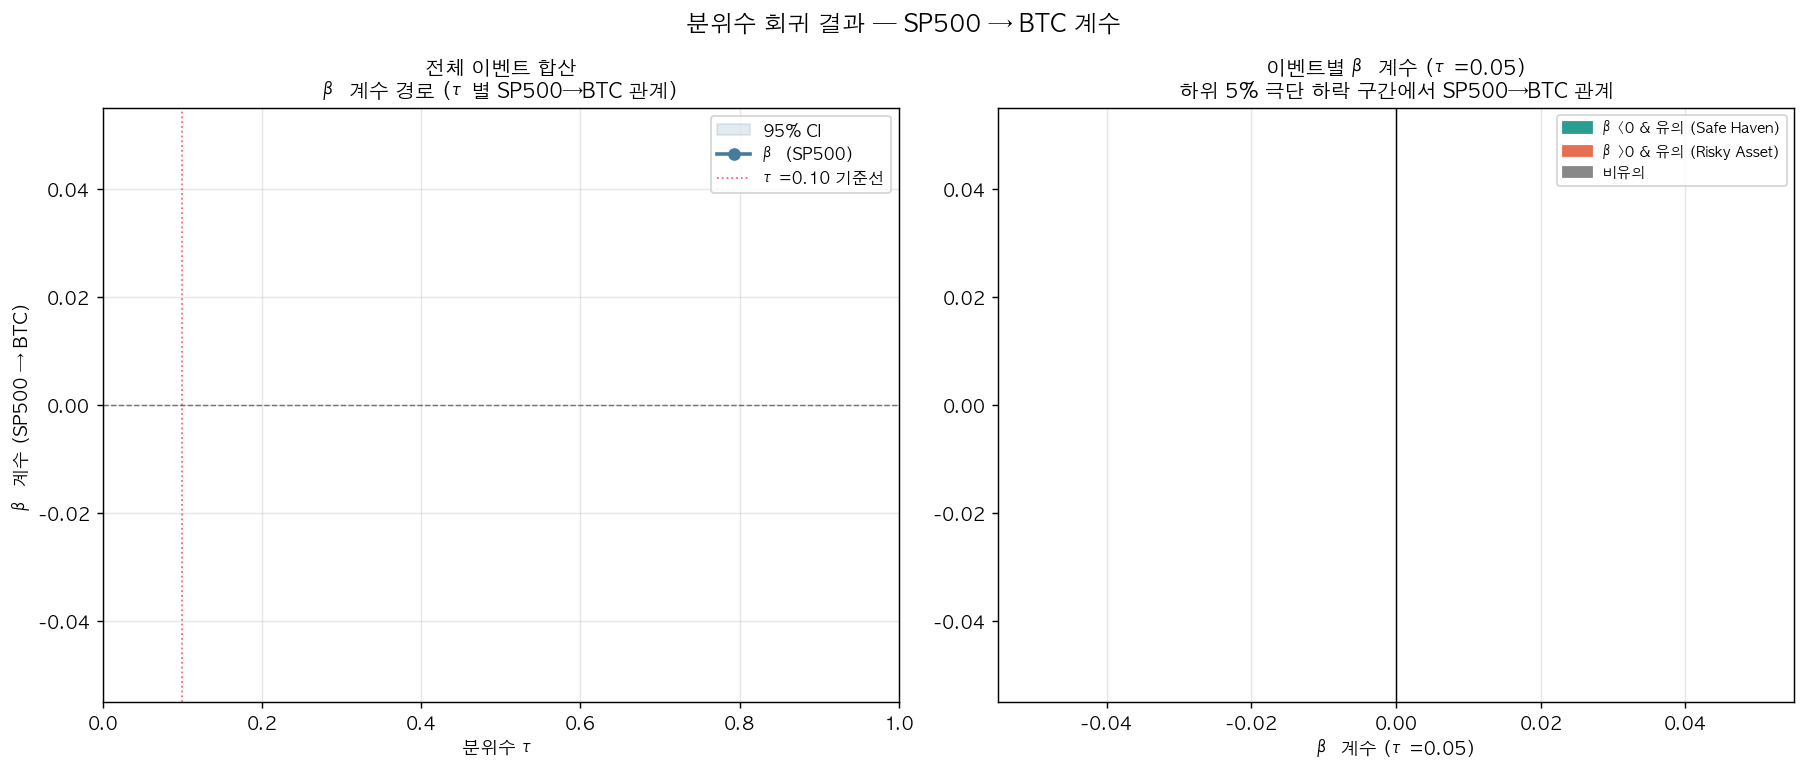

✅ quantreg_beta_path.png 저장


In [7]:
# ── 5-1. β 계수 경로 (Coefficient Plot) ─────────────
# τ가 증가할수록 β가 어떻게 변하는지 → Safe-Haven이면 하위 τ에서 β < 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 전체 합산 β 경로
ax = axes[0]
taus_done = [t for t in TAUS if results_all.get(t) is not None]
betas, ci_lo, ci_hi = [], [], []

for tau in taus_done:
    res = results_all[tau]
    x_cols = res['x_cols']
    sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
    if sp_i is not None:
        betas.append(res['params'][sp_i])
        ci_lo.append(res['conf_int'][sp_i, 0])
        ci_hi.append(res['conf_int'][sp_i, 1])
    else:
        betas.append(np.nan)
        ci_lo.append(np.nan)
        ci_hi.append(np.nan)

betas  = np.array(betas)
ci_lo  = np.array(ci_lo)
ci_hi  = np.array(ci_hi)

ax.fill_between(taus_done, ci_lo, ci_hi, alpha=0.15, color='#457B9D', label='95% CI')
ax.plot(taus_done, betas, 'o-', color='#457B9D', lw=2, ms=6, label='β (SP500)')
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0.10, color='red', lw=1, ls=':', alpha=0.6, label='τ=0.10 기준선')
_valid_lo = ci_lo[np.isfinite(ci_lo)]
_valid_hi = ci_hi[np.isfinite(ci_hi)]
if len(_valid_lo) > 0 and len(_valid_hi) > 0:
    ax.fill_betweenx([_valid_lo.min()-0.01,
                       _valid_hi.max()+0.01],
                      0, 0.10, alpha=0.06, color='red')
ax.set_xlabel('분위수 τ')
ax.set_ylabel('β 계수 (SP500 → BTC)')
ax.set_title('전체 이벤트 합산\nβ 계수 경로 (τ별 SP500→BTC 관계)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)

# 이벤트별 τ=0.05 β 비교
ax2 = axes[1]
ev_names, ev_betas, ev_colors = [], [], []
for event in EVENT_DATES:
    res = results_event.get(event, {}).get(0.05)
    if res is None:
        continue
    x_cols = res['x_cols']
    sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
    if sp_i is None:
        continue
    b  = res['params'][sp_i]
    pb = res['pvalues'][sp_i]
    ev_names.append(EVENT_LABELS.get(event, event))
    ev_betas.append(b)
    ev_colors.append('#2A9D8F' if (pb<0.05 and b<0)
                     else '#E76F51' if (pb<0.05 and b>0)
                     else '#888')

bars = ax2.barh(ev_names, ev_betas, color=ev_colors, alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_xlabel('β 계수 (τ=0.05)')
ax2.set_title('이벤트별 β 계수 (τ=0.05)\n하위 5% 극단 하락 구간에서 SP500→BTC 관계',
               fontsize=11, fontweight='bold')

legend_els = [
    mpatches.Patch(color='#2A9D8F', label='β<0 & 유의 (Safe Haven)'),
    mpatches.Patch(color='#E76F51', label='β>0 & 유의 (Risky Asset)'),
    mpatches.Patch(color='#888',    label='비유의'),
]
ax2.legend(handles=legend_els, fontsize=8)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('분위수 회귀 결과 — SP500 → BTC 계수', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('quantreg_beta_path.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ quantreg_beta_path.png 저장')

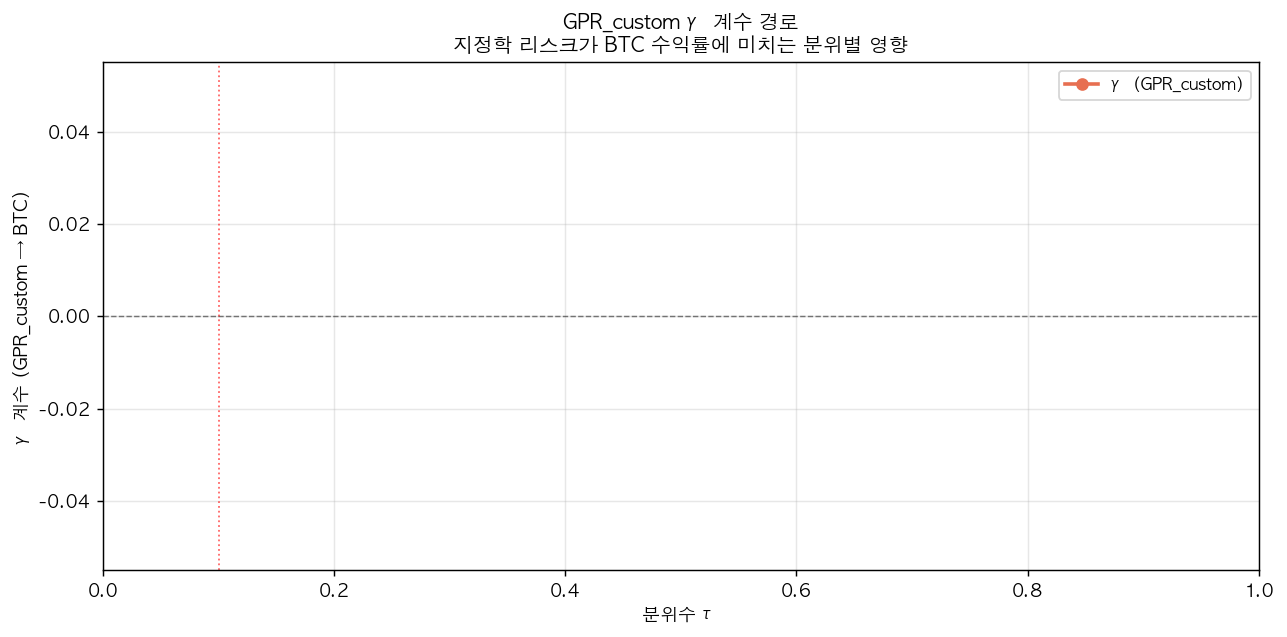

✅ quantreg_gamma_path.png 저장


In [8]:
# ── 5-2. γ 계수 경로 (GPR_custom → BTC) ─────────────
fig, ax = plt.subplots(figsize=(10, 5))

gammas, g_ci_lo, g_ci_hi = [], [], []
for tau in taus_done:
    res    = results_all[tau]
    x_cols = res['x_cols']
    gpr_i  = x_cols.index('GPR_custom_z') if 'GPR_custom_z' in x_cols else None
    if gpr_i is not None:
        gammas.append(res['params'][gpr_i])
        g_ci_lo.append(res['conf_int'][gpr_i, 0])
        g_ci_hi.append(res['conf_int'][gpr_i, 1])
    else:
        gammas.append(np.nan)
        g_ci_lo.append(np.nan)
        g_ci_hi.append(np.nan)

gammas  = np.array(gammas)
g_ci_lo = np.array(g_ci_lo)
g_ci_hi = np.array(g_ci_hi)

ax.fill_between(taus_done, g_ci_lo, g_ci_hi, alpha=0.15, color='#E76F51')
ax.plot(taus_done, gammas, 'o-', color='#E76F51', lw=2, ms=6, label='γ (GPR_custom)')
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0.10, color='red', lw=1, ls=':', alpha=0.6)
ax.set_xlabel('분위수 τ')
ax.set_ylabel('γ 계수 (GPR_custom → BTC)')
ax.set_title('GPR_custom γ 계수 경로\n지정학 리스크가 BTC 수익률에 미치는 분위별 영향',
              fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('quantreg_gamma_path.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ quantreg_gamma_path.png 저장')

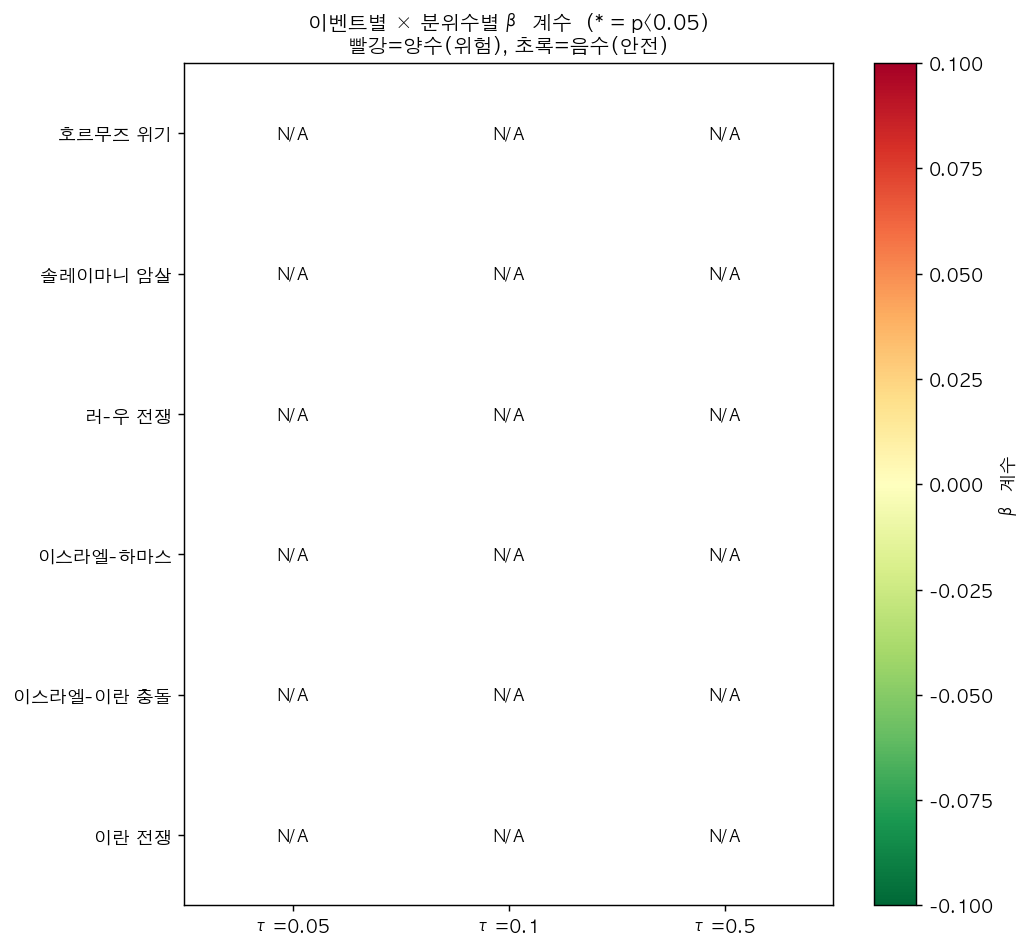

✅ quantreg_heatmap.png 저장


In [9]:
# ── 5-3. 이벤트별 × τ별 히트맵 ──────────────────────
# τ=0.05, 0.10, 0.50에서 이벤트별 β 색깔로 표시

events_list = [ev for ev in EVENT_DATES if results_event.get(ev)]
tau_list    = CORE_TAUS

beta_matrix = np.full((len(events_list), len(tau_list)), np.nan)
sig_matrix  = np.full((len(events_list), len(tau_list)), False)

for i, ev in enumerate(events_list):
    for j, tau in enumerate(tau_list):
        res = results_event.get(ev, {}).get(tau)
        if res is None:
            continue
        x_cols = res['x_cols']
        sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
        if sp_i is not None:
            beta_matrix[i, j] = res['params'][sp_i]
            sig_matrix[i, j]  = res['pvalues'][sp_i] < 0.05

fig, ax = plt.subplots(figsize=(8, max(4, len(events_list)*0.9+2)))
vabs = np.nanmax(np.abs(beta_matrix))
im = ax.imshow(beta_matrix, cmap='RdYlGn_r', vmin=-vabs, vmax=vabs, aspect='auto')
plt.colorbar(im, ax=ax, label='β 계수')

for i in range(len(events_list)):
    for j in range(len(tau_list)):
        val = beta_matrix[i, j]
        txt = f'{val:.3f}' if not np.isnan(val) else 'N/A'
        star = '*' if sig_matrix[i, j] else ''
        color = 'white' if abs(val) > vabs*0.5 and not np.isnan(val) else 'black'
        ax.text(j, i, f'{txt}{star}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_xticks(range(len(tau_list)))
ax.set_xticklabels([f'τ={t}' for t in tau_list])
ax.set_yticks(range(len(events_list)))
ax.set_yticklabels([EVENT_LABELS.get(e,e) for e in events_list])
ax.set_title('이벤트별 × 분위수별 β 계수  (* = p<0.05)\n빨강=양수(위험), 초록=음수(안전)',
              fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('quantreg_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ quantreg_heatmap.png 저장')

---
## Step 6. 최종 판단 — Baur & Lucey (2010)

In [10]:
print('=' * 75)
print('분위수 회귀 Safe-Haven 최종 판단')
print('=' * 75)
print()
print('[전체 이벤트 합산]\n')
print(f'{"τ":>6} {"β(SP500)":>10} {"p(β)":>8} {"유의":>6} {"결론"}')
print('-' * 55)

for tau in CORE_TAUS:
    res = results_all.get(tau)
    if res is None:
        print(f'{tau:>6.2f}  데이터 부족')
        continue
    x_cols = res['x_cols']
    sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
    if sp_i is None:
        continue
    b   = res['params'][sp_i]
    pb  = res['pvalues'][sp_i]
    sig = '✅' if pb < 0.05 else '—'
    if tau <= 0.10:
        if pb<0.05 and b<0:
            verdict = '✅ Safe Haven — 주가 폭락 시 BTC 반대 방향'
        elif pb<0.05 and b>0:
            verdict = '❌ Risky Asset — 주가 폭락 시 BTC도 하락'
        else:
            verdict = '⚪ 비유의 — 통계적으로 불확실'
    else:
        verdict = f'평상시 β={b:.4f}  (비교용)'
    print(f'{tau:>6.2f} {b:>10.5f} {pb:>8.4f} {sig:>6}  {verdict}')

print()
print('[이벤트별 Safe-Haven 판정 요약]\n')
summary_rows = []
for ev in EVENT_DATES:
    row = {'이벤트': EVENT_LABELS.get(ev, ev)}
    for tau in CORE_TAUS:
        res = results_event.get(ev, {}).get(tau)
        if res is None:
            row[f'τ={tau}'] = 'N/A'
            continue
        x_cols = res['x_cols']
        sp_i   = x_cols.index('SP500_z') if 'SP500_z' in x_cols else None
        if sp_i is None:
            row[f'τ={tau}'] = 'N/A'
            continue
        b  = res['params'][sp_i]
        pb = res['pvalues'][sp_i]
        if tau <= 0.10:
            if pb<0.05 and b<0:
                row[f'τ={tau}'] = '✅ SH'
            elif pb<0.05 and b>0:
                row[f'τ={tau}'] = '❌ RA'
            elif b<0:
                row[f'τ={tau}'] = '🔵 Weak'
            else:
                row[f'τ={tau}'] = '⚪'
        else:
            row[f'τ={tau}'] = f'{b:+.4f}'
    summary_rows.append(row)

display(pd.DataFrame(summary_rows).set_index('이벤트'))

분위수 회귀 Safe-Haven 최종 판단

[전체 이벤트 합산]

     τ   β(SP500)     p(β)     유의 결론
-------------------------------------------------------
  0.05  데이터 부족
  0.10  데이터 부족
  0.50  데이터 부족

[이벤트별 Safe-Haven 판정 요약]



,τ=0.05,τ=0.1,τ=0.5
이벤트,,,
호르무즈 위기,N/A,N/A,N/A
솔레이마니 암살,N/A,N/A,N/A
러-우 전쟁,N/A,N/A,N/A
이스라엘-하마스,N/A,N/A,N/A
이스라엘-이란 충돌,N/A,N/A,N/A
이란 전쟁,N/A,N/A,N/A


---
## Step 7. 결과 저장

In [11]:
# 전체 결과 테이블
all_rows = []
for tau in TAUS:
    res = results_all.get(tau)
    if res is None:
        continue
    x_cols  = res['x_cols']
    sp_i    = x_cols.index('SP500_z')     if 'SP500_z'     in x_cols else None
    gpr_i   = x_cols.index('GPR_custom_z') if 'GPR_custom_z' in x_cols else None
    const_i = x_cols.index('const')
    all_rows.append({
        'scope' : '전체',
        'event' : 'all',
        'tau'   : tau,
        'n'     : res['n'],
        'alpha' : round(res['params'][const_i], 6),
        'beta_sp500'  : round(res['params'][sp_i],  6) if sp_i  is not None else np.nan,
        'p_beta'      : round(res['pvalues'][sp_i], 4) if sp_i  is not None else np.nan,
        'gamma_gpr'   : round(res['params'][gpr_i], 6) if gpr_i is not None else np.nan,
        'p_gamma'     : round(res['pvalues'][gpr_i],4) if gpr_i is not None else np.nan,
    })

for ev in EVENT_DATES:
    for tau in CORE_TAUS:
        res = results_event.get(ev, {}).get(tau)
        if res is None:
            continue
        x_cols  = res['x_cols']
        sp_i    = x_cols.index('SP500_z')     if 'SP500_z'     in x_cols else None
        gpr_i   = x_cols.index('GPR_custom_z') if 'GPR_custom_z' in x_cols else None
        const_i = x_cols.index('const')
        all_rows.append({
            'scope' : '이벤트별',
            'event' : ev,
            'tau'   : tau,
            'n'     : res['n'],
            'alpha' : round(res['params'][const_i], 6),
            'beta_sp500'  : round(res['params'][sp_i],  6) if sp_i  is not None else np.nan,
            'p_beta'      : round(res['pvalues'][sp_i], 4) if sp_i  is not None else np.nan,
            'gamma_gpr'   : round(res['params'][gpr_i], 6) if gpr_i is not None else np.nan,
            'p_gamma'     : round(res['pvalues'][gpr_i],4) if gpr_i is not None else np.nan,
        })

result_df = pd.DataFrame(all_rows)
result_df.to_csv('quantreg_results.csv', index=False, encoding='utf-8-sig')

print('▶ 최종 산출물:')
for f in ['quantreg_results.csv',
          'quantreg_beta_path.png',
          'quantreg_gamma_path.png',
          'quantreg_heatmap.png']:
    flag = '✅' if os.path.exists(f) else '📄 (실행 후 생성)'
    print(f'  {flag} {f}')

▶ 최종 산출물:
  ✅ quantreg_results.csv
  ✅ quantreg_beta_path.png
  ✅ quantreg_gamma_path.png
  ✅ quantreg_heatmap.png


---
## Step 8. 강건성 검정 (4종)

### 강건성 ① GPR 제거 검정

GPR_custom 제거 후 β 재추정 — GPR이 SP500·Gold 효과를 왜곡하는지 확인

In [12]:
# ══════════════════════════════════════════════════════
# 강건성 ② 독립변수 변경 검정
# SP500: GPR 포함 vs 제거
# Gold:  GPR 포함 vs 제거
# ══════════════════════════════════════════════════════

print('▶ 강건성 ② 독립변수 변경 검정 (전체 합산)\n')
print('  [기존] Q_τ(BTC) = α + β·X + γ·GPR_custom_z')
print('  [수정] Q_τ(BTC) = α + β·X  (GPR 제거)')
print('  → GPR이 X(SP500/Gold)의 β 추정을 왜곡하는지 확인\n')

# 검정할 자산 × 모델 조합
ROBUST_TARGETS = {
    'SP500': {
        'with_gpr': ['SP500_z', 'GPR_custom_z'],
        'without' : ['SP500_z'],
        'main_var': 'SP500_z',
    },
    'Gold': {
        'with_gpr': ['Gold_z', 'GPR_custom_z'],
        'without' : ['Gold_z'],
        'main_var': 'Gold_z',
    },
}

robust_iv_rows = []

for asset_name, cfg in ROBUST_TARGETS.items():

    print(f'  {"─"*60}')
    print(f'  [{asset_name}]')
    print(f'  기존: Q_τ(BTC) = α + β·{cfg["main_var"]} + γ·GPR_custom_z')
    print(f'  수정: Q_τ(BTC) = α + β·{cfg["main_var"]}')
    print(f'  {"─"*60}')
    print(f'  {"τ":>6} {"β 기존":>10} {"p 기존":>8} '
          f'{"β 수정":>10} {"p 수정":>8} '
          f'{"차이":>9} {"변화율":>8} {"방향일치":>10} {"판정"}')
    print('  ' + '-' * 90)

    asset_rows = []

    for tau in TAUS:                        # CORE_TAUS → TAUS 전체로 확장
        # ── 기존: GPR 포함 ────────────────────────────────────
        res_with = run_quantreg_hac(        # ← run_quantreg → run_quantreg_hac
            data_all, tau,
            x_cols=cfg['with_gpr']
        )
        # ── 수정: GPR 제거 ────────────────────────────────────
        res_wo = run_quantreg_hac(
            data_all, tau,
            x_cols=cfg['without']
        )

        if res_with is None or res_wo is None:
            print(f'  {tau:>6.2f}  데이터 부족')
            continue

        main_var = cfg['main_var']
        x_with   = res_with['x_cols']
        x_wo     = res_wo['x_cols']

        i_with = x_with.index(main_var) if main_var in x_with else None
        i_wo   = x_wo.index(main_var)   if main_var in x_wo   else None

        if i_with is None or i_wo is None:
            print(f'  {tau:>6.2f}  변수 인덱스 오류')
            continue

        b_with  = res_with['params'][i_with]
        pb_with = res_with['pvalues'][i_with]
        b_wo    = res_wo['params'][i_wo]
        pb_wo   = res_wo['pvalues'][i_wo]

        diff = b_wo - b_with

        # ── 변화율 (b_with=0 방어) ────────────────────────────
        if abs(b_with) > 1e-10:
            change_pct = diff / abs(b_with) * 100
            change_str = f'{change_pct:>+7.1f}%'
        else:
            change_str = '   N/A  '

        # ── 방향 일치 판정 (0값 엣지케이스 방어) ─────────────
        if abs(b_with) < 1e-10 or abs(b_wo) < 1e-10:
            same_dir = '⚠️ 0근접'
        elif b_with * b_wo > 0:
            same_dir = '✅ 일치'
        else:
            same_dir = '🔴 반전'

        # ── 크기 변화 판정 ────────────────────────────────────
        if same_dir == '✅ 일치':
            if abs(b_with) > 1e-10:
                ratio = abs(b_wo) / abs(b_with)
                if ratio > 1.20:
                    size_judge = 'β 20% 이상 증폭'
                elif ratio < 0.80:
                    size_judge = 'β 20% 이상 감소'
                else:
                    size_judge = 'β 안정적 (±20% 이내)'
            else:
                size_judge = '—'
        else:
            size_judge = '⚠️ 방향 반전 → GPR 왜곡 의심'

        sig_with = '✅' if pb_with < 0.05 else '△' if pb_with < 0.10 else '—'
        sig_wo   = '✅' if pb_wo   < 0.05 else '△' if pb_wo   < 0.10 else '—'

        print(f'  {tau:>6.2f} '
              f'{b_with:>10.5f}{sig_with:>2} {pb_with:>7.4f} '
              f'{b_wo:>10.5f}{sig_wo:>2} {pb_wo:>7.4f} '
              f'{diff:>+9.5f} {change_str:>8} '
              f'{same_dir:>10}  {size_judge}')

        asset_rows.append({
            '자산'      : asset_name,
            'τ'         : tau,
            'β_기존'    : round(b_with, 5),
            'p_기존'    : round(pb_with, 4),
            'β_GPR제거' : round(b_wo, 5),
            'p_GPR제거' : round(pb_wo, 4),
            '차이'      : round(diff, 5),
            '방향일치'  : same_dir,
            '판정'      : size_judge,
        })
        robust_iv_rows.append(asset_rows[-1])

    # ── 자산별 소결론 ──────────────────────────────────────
    if asset_rows:
        match_count   = sum(1 for r in asset_rows if '일치' in r['방향일치'])
        reverse_count = sum(1 for r in asset_rows if '반전' in r['방향일치'])
        total         = len(asset_rows)

        print(f'\n  ▶ [{asset_name}] 소결론')
        print(f'     방향 일치: {match_count}/{total}개 분위수')

        if reverse_count == 0:
            print(f'     ✅ GPR 제거해도 β 방향 동일')
            print(f'        → {asset_name} 효과가 GPR 포함 여부와 무관 (강건)')
        elif reverse_count <= total * 0.3:
            print(f'     🔶 일부({reverse_count}개) 분위수에서 방향 반전')
            print(f'        → 특정 구간에서 GPR이 {asset_name} 효과 추정에 영향')
        else:
            print(f'     🔴 과반({reverse_count}개) 방향 반전')
            print(f'        → GPR이 {asset_name} 효과 추정을 심하게 왜곡')
    print()

# ── 전체 요약 ──────────────────────────────────────────────
print('═' * 60)
print('▶ 강건성 ② 최종 요약')
print('═' * 60)

for asset_name in ROBUST_TARGETS:
    rows_asset = [r for r in robust_iv_rows if r['자산'] == asset_name]
    if not rows_asset:
        continue
    match   = sum(1 for r in rows_asset if '일치' in r['방향일치'])
    reverse = sum(1 for r in rows_asset if '반전' in r['방향일치'])
    total   = len(rows_asset)
    icon    = '✅' if reverse == 0 else '🔶' if reverse <= total*0.3 else '🔴'
    print(f'  {icon} {asset_name:<8} '
          f'방향일치 {match}/{total}  '
          f'{"GPR 포함 여부와 무관 (강건)" if reverse==0 else "GPR 왜곡 존재"}')

# DataFrame 저장
robust_iv_df = pd.DataFrame(robust_iv_rows)
print(f'\n  robust_iv_df: {len(robust_iv_df)}행 저장 완료')

▶ 강건성 ② 독립변수 변경 검정 (전체 합산)

  [기존] Q_τ(BTC) = α + β·X + γ·GPR_custom_z
  [수정] Q_τ(BTC) = α + β·X  (GPR 제거)
  → GPR이 X(SP500/Gold)의 β 추정을 왜곡하는지 확인

  ────────────────────────────────────────────────────────────
  [SP500]
  기존: Q_τ(BTC) = α + β·SP500_z + γ·GPR_custom_z
  수정: Q_τ(BTC) = α + β·SP500_z
  ────────────────────────────────────────────────────────────
       τ       β 기존     p 기존       β 수정     p 수정        차이      변화율       방향일치 판정
  ------------------------------------------------------------------------------------------
    0.01    0.02552 ✅  0.0000    0.02558 ✅  0.0000  +0.00006    +0.2%       ✅ 일치  β 안정적 (±20% 이내)
    0.03    0.02099 ✅  0.0000    0.01968 ✅  0.0000  -0.00131    -6.2%       ✅ 일치  β 안정적 (±20% 이내)
    0.05    0.01786 ✅  0.0000    0.01757 ✅  0.0000  -0.00029    -1.6%       ✅ 일치  β 안정적 (±20% 이내)
    0.10    0.01585 ✅  0.0000    0.01600 ✅  0.0000  +0.00014    +0.9%       ✅ 일치  β 안정적 (±20% 이내)
    0.20    0.01303 ✅  0.0000    0.01324 ✅  0.0000  +0.00021    +1.6%  

**결과**: SP500 모델 방향 일치·최대 변화율 8.5%, Gold 모델 최대 14.8% — 결론 안정

### 강건성 ② LOO (Leave-One-Out)

이벤트 하나씩 제외 후 전체 재추정 — 특정 이벤트가 결론을 지배하는지 확인

In [13]:
# ══════════════════════════════════════════════════════
# 강건성 ③ Leave-One-Out 검정
# ══════════════════════════════════════════════════════

def get_beta(res, var):
    """결과에서 특정 변수의 β, p 추출 헬퍼"""
    if res is None:
        return np.nan, np.nan
    x_cols = res['x_cols']
    if var not in x_cols:
        return np.nan, np.nan
    i = x_cols.index(var)
    return res['params'][i], res['pvalues'][i]


def classify_verdict(b, p):
    """β, p → 판정 문자열"""
    if pd.isna(b) or pd.isna(p):
        return '판정불가'
    if p < 0.05 and b < 0:
        return 'Safe Haven'
    if p < 0.05 and b > 0:
        return 'Risky Asset'
    if p < 0.10 and b < 0:
        return 'Weak SH'
    return '비유의'


def verdict_changed(v_base, v_loo):
    """판정 변화 여부 및 심각도"""
    if v_base == v_loo:
        return '✅ 동일'
    # Safe Haven ↔ Risky Asset 반전은 가장 심각
    critical = {'Safe Haven', 'Risky Asset'}
    if v_base in critical and v_loo in critical:
        return '🔴 판정 반전!'
    return '⚠️ 판정 변화'


# ── 검정 대상 자산 정의 ───────────────────────────────────────────
LOO_TARGETS = {
    'SP500': {
        'x_cols'  : ['SP500_z', 'GPR_custom_z'],
        'main_var': 'SP500_z',
    },
    'Gold': {
        'x_cols'  : ['Gold_z', 'GPR_custom_z'],
        'main_var': 'Gold_z',
    },
}

print('▶ 강건성 ③ Leave-One-Out 검정\n')
print('  이벤트를 하나씩 제외했을 때 전체 결과가 얼마나 변하는지 확인')
print('  → 특정 이벤트가 결론을 지배하는지 파악\n')

loo_rows    = []
all_results = {}   # 자산별 LOO 결과 저장

for asset_name, cfg in LOO_TARGETS.items():
    main_var = cfg['main_var']
    x_cols   = cfg['x_cols']

    print(f'\n{"═"*85}')
    print(f'  [{asset_name}]  '
          f'모델: BTC = α + β·{main_var} + γ·GPR_custom_z')
    print(f'{"═"*85}')

    # ── 기준선: 전체 데이터 ───────────────────────────────────
    res_base_05 = run_quantreg_hac(data_all, 0.05, x_cols=x_cols)
    res_base_10 = run_quantreg_hac(data_all, 0.10, x_cols=x_cols)

    b05_base, p05_base = get_beta(res_base_05, main_var)
    b10_base, p10_base = get_beta(res_base_10, main_var)

    v05_base = classify_verdict(b05_base, p05_base)
    v10_base = classify_verdict(b10_base, p10_base)

    sig05 = '✅' if p05_base < 0.05 else '△' if p05_base < 0.10 else '—'
    sig10 = '✅' if p10_base < 0.05 else '△' if p10_base < 0.10 else '—'

    # 헤더
    print(f'\n  {"제외 이벤트":<24} '
          f'{"τ=0.05 β":>10} {"p":>7} {"판정05":<14} '
          f'{"τ=0.10 β":>10} {"p":>7} {"판정10":<14} '
          f'{"결론 변화"}')
    print('  ' + '-' * 105)

    # 기준선 출력
    print(f'  {"[전체 포함 기준]":<24} '
          f'{b05_base:>10.5f}{sig05} {p05_base:>6.4f} {v05_base:<14} '
          f'{b10_base:>10.5f}{sig10} {p10_base:>6.4f} {v10_base:<14} '
          f'(기준선)')
    print('  ' + '-' * 105)

    asset_loo_rows = []

    for excl_event, excl_label in EVENT_LABELS.items():

        # 해당 이벤트 제외
        data_loo = data_all[
            data_all['event_name'] != excl_event
        ].copy()

        n_loo = len(data_loo.dropna(
            subset=['BTC'] + [c for c in x_cols if c in data_loo.columns]
        ))

        if n_loo < 30:
            print(f'  {excl_label:<24}  ⚠️ n={n_loo} < 30 → 스킵')
            continue

        # LOO 분위수 회귀
        res_05 = run_quantreg_hac(data_loo, 0.05, x_cols=x_cols)
        res_10 = run_quantreg_hac(data_loo, 0.10, x_cols=x_cols)

        b05, p05 = get_beta(res_05, main_var)
        b10, p10 = get_beta(res_10, main_var)

        v05 = classify_verdict(b05, p05)
        v10 = classify_verdict(b10, p10)

        # 변화 판정
        chg05 = verdict_changed(v05_base, v05)
        chg10 = verdict_changed(v10_base, v10)

        # 더 심각한 쪽으로 전체 판정
        if '반전' in chg05 or '반전' in chg10:
            overall = '🔴 판정 반전!'
        elif '변화' in chg05 or '변화' in chg10:
            overall = '⚠️ 판정 변화'
        else:
            overall = '✅ 동일'

        # β 변화량
        diff05 = b05 - b05_base
        diff10 = b10 - b10_base

        sig05_loo = '✅' if p05 < 0.05 else '△' if p05 < 0.10 else '—'
        sig10_loo = '✅' if p10 < 0.05 else '△' if p10 < 0.10 else '—'

        print(f'  {excl_label:<24} '
              f'{b05:>10.5f}{sig05_loo} {p05:>6.4f} {v05:<14} '
              f'{b10:>10.5f}{sig10_loo} {p10:>6.4f} {v10:<14} '
              f'{overall}')

        row = {
            '자산'       : asset_name,
            '제외이벤트' : excl_label,
            'n_loo'      : n_loo,
            'β_τ0.05'    : round(b05, 5),
            'p_τ0.05'    : round(p05, 4),
            'v_τ0.05'    : v05,
            'Δβ_0.05'    : round(diff05, 5),
            'β_τ0.10'    : round(b10, 5),
            'p_τ0.10'    : round(p10, 4),
            'v_τ0.10'    : v10,
            'Δβ_0.10'    : round(diff10, 5),
            '결론변화'   : overall,
        }
        asset_loo_rows.append(row)
        loo_rows.append(row)

    # ── 자산별 영향력 순위 ─────────────────────────────────
    if asset_loo_rows:
        print(f'\n  ▶ [{asset_name}] β 변화량 순위 (τ=0.05 기준, 영향 큰 순)')
        sorted_rows = sorted(asset_loo_rows,
                             key=lambda r: abs(r['Δβ_0.05']),
                             reverse=True)
        for rank, r in enumerate(sorted_rows, 1):
            bar_len = int(abs(r['Δβ_0.05']) / 0.001)   # 스케일 조정
            bar     = '█' * min(bar_len, 30)
            sign    = '+' if r['Δβ_0.05'] > 0 else '-'
            print(f'    {rank}위 {r["제외이벤트"]:<22} '
                  f'Δβ={r["Δβ_0.05"]:>+8.5f}  {sign}{bar}')

        # 소결론
        changed = sum(1 for r in asset_loo_rows if '동일' not in r['결론변화'])
        reverse = sum(1 for r in asset_loo_rows if '반전' in r['결론변화'])
        total   = len(asset_loo_rows)

        print(f'\n  ▶ [{asset_name}] 소결론')
        print(f'     판정 변화: {changed}/{total}개 이벤트 제외 시 변화')
        print(f'     판정 반전: {reverse}/{total}개 이벤트 제외 시 반전')

        if reverse == 0 and changed == 0:
            print(f'     ✅ 강건: 어떤 이벤트 제외해도 결론 동일')
        elif reverse > 0:
            # 반전 일으킨 이벤트 명시
            culprits = [r['제외이벤트'] for r in asset_loo_rows
                        if '반전' in r['결론변화']]
            print(f'     🔴 취약: {culprits} 제외 시 판정 반전')
            print(f'        → 해당 이벤트가 결론을 지배하고 있음')
        else:
            print(f'     🔶 주의: 일부 제외 시 판정 변화 (반전은 없음)')

        all_results[asset_name] = {
            'base': {'b05': b05_base, 'p05': p05_base,
                     'b10': b10_base, 'p10': p10_base},
            'loo' : asset_loo_rows,
        }

# ══════════════════════════════════════════════════════
# 최종 요약
# ══════════════════════════════════════════════════════
print(f'\n\n{"═"*85}')
print('▶ 강건성 ③ LOO 최종 요약')
print(f'{"═"*85}')
print(f'  {"자산":<10} {"강건성":>8} {"반전 이벤트"}')
print('  ' + '-' * 60)

for asset_name in LOO_TARGETS:
    rows_a  = [r for r in loo_rows if r['자산'] == asset_name]
    reverse = [r['제외이벤트'] for r in rows_a if '반전' in r['결론변화']]
    changed = [r['제외이벤트'] for r in rows_a if '변화' in r['결론변화']
               and '반전' not in r['결론변화']]

    if not reverse and not changed:
        icon   = '✅ 강건'
        detail = '없음'
    elif reverse:
        icon   = '🔴 취약'
        detail = ', '.join(reverse)
    else:
        icon   = '🔶 주의'
        detail = ', '.join(changed)

    print(f'  {asset_name:<10} {icon:<10} {detail}')

# DataFrame 저장
loo_df = pd.DataFrame(loo_rows)
print(f'\n  loo_df: {len(loo_df)}행 저장 완료')

▶ 강건성 ③ Leave-One-Out 검정

  이벤트를 하나씩 제외했을 때 전체 결과가 얼마나 변하는지 확인
  → 특정 이벤트가 결론을 지배하는지 파악


═════════════════════════════════════════════════════════════════════════════════════
  [SP500]  모델: BTC = α + β·SP500_z + γ·GPR_custom_z
═════════════════════════════════════════════════════════════════════════════════════

  제외 이벤트                     τ=0.05 β       p 판정05             τ=0.10 β       p 판정10           결론 변화
  ---------------------------------------------------------------------------------------------------------
  [전체 포함 기준]                  0.01786✅ 0.0000 Risky Asset       0.01585✅ 0.0000 Risky Asset    (기준선)
  ---------------------------------------------------------------------------------------------------------
  호르무즈 위기                     0.01817✅ 0.0000 Risky Asset       0.01599✅ 0.0000 Risky Asset    ✅ 동일
  솔레이마니 암살                    0.01970✅ 0.0000 Risky Asset       0.01665✅ 0.0000 Risky Asset    ✅ 동일
  러-우 전쟁                      0.01401✅ 0.0000 Risky Asset       0.0

**결과**: SP500 모델 6개 이벤트 제외 후 결론 유지. Gold 모델은 호르무즈·솔레이마니 제외 시 일부 비유의 전환.

### 강건성 ③ Min-Max 표준화

Z-score → Min-Max 표준화로 변경 후 β 방향·유의성 비교

In [14]:
# ══════════════════════════════════════════════════════
# 강건성 ④ 표준화 방법 변경 검정
# Z-score vs Min-Max 정규화
# SP500+GPR / Gold+GPR 두 모델 모두 검정
# ══════════════════════════════════════════════════════

# ── Min-Max 정규화 데이터 생성 ────────────────────────
norm_cols = ['SP500', 'Gold', 'GPR_custom']
data_minmax = data_all.copy()

print('▶ Min-Max 정규화 컬럼 생성')
for col in norm_cols:
    if col not in data_minmax.columns:
        print(f'  ⚠️  {col} 없음 → 스킵')
        continue
    cmin = data_minmax[col].min()
    cmax = data_minmax[col].max()
    mm_col = f'{col}_mm'
    if cmax > cmin:
        data_minmax[mm_col] = (data_minmax[col] - cmin) / (cmax - cmin)
    else:
        data_minmax[mm_col] = 0.0
        print(f'  ⚠️  {col}: min=max → 0으로 채움')
    print(f'  {col:<15} → {mm_col}  '
          f'범위: [{data_minmax[mm_col].min():.3f}, '
          f'{data_minmax[mm_col].max():.3f}]')

# ── 검정 대상 모델 정의 ───────────────────────────────
NORM_TARGETS = {
    'SP500+GPR': {
        'z_cols' : ['SP500_z',  'GPR_custom_z'],
        'mm_cols': ['SP500_mm', 'GPR_custom_mm'],
        'main_z' : 'SP500_z',
        'main_mm': 'SP500_mm',
        'gpr_z'  : 'GPR_custom_z',
        'gpr_mm' : 'GPR_custom_mm',
    },
    'Gold+GPR': {
        'z_cols' : ['Gold_z',  'GPR_custom_z'],
        'mm_cols': ['Gold_mm', 'GPR_custom_mm'],
        'main_z' : 'Gold_z',
        'main_mm': 'Gold_mm',
        'gpr_z'  : 'GPR_custom_z',
        'gpr_mm' : 'GPR_custom_mm',
    },
}

robust_mm_rows = []

print('\n▶ 강건성 ④ 표준화 방법 변경 검정\n')
print('  [기존] Z-score  (평균=0, 표준편차=1)')
print('  [수정] Min-Max  (0~1 범위)')
print('  → β 절댓값은 달라지지만 방향·유의성은 유지돼야 강건\n')

for model_name, cfg in NORM_TARGETS.items():

    print(f'{"═"*80}')
    print(f'  [{model_name}]')
    print(f'  기존: BTC = α + β·{cfg["main_z"]}  + γ·{cfg["gpr_z"]}')
    print(f'  수정: BTC = α + β·{cfg["main_mm"]} + γ·{cfg["gpr_mm"]}')
    print(f'{"═"*80}')
    print(f'  {"τ":>6} '
          f'{"β(Z)":>10} {"p(Z)":>7} '
          f'{"β(MM)":>10} {"p(MM)":>7} '
          f'{"γ(Z)":>10} {"p(γZ)":>7} '
          f'{"γ(MM)":>10} {"p(γMM)":>7} '
          f'{"방향":>8} {"유의성":>8} {"판정"}')
    print('  ' + '-' * 110)

    model_rows = []

    for tau in TAUS:

        # ── Z-score 모델 ───────────────────────────────
        res_z = run_quantreg_hac(
            data_all, tau,
            x_cols=cfg['z_cols']
        )
        # ── Min-Max 모델 ──────────────────────────────
        res_mm = run_quantreg_hac(
            data_minmax, tau,
            x_cols=cfg['mm_cols']
        )

        if res_z is None or res_mm is None:
            print(f'  {tau:>6.2f}  데이터 부족')
            continue

        xz  = res_z['x_cols']
        xmm = res_mm['x_cols']

        # 인덱스 추출
        m_z_i   = xz.index(cfg['main_z'])   if cfg['main_z']  in xz  else None
        m_mm_i  = xmm.index(cfg['main_mm']) if cfg['main_mm'] in xmm else None
        g_z_i   = xz.index(cfg['gpr_z'])    if cfg['gpr_z']   in xz  else None
        g_mm_i  = xmm.index(cfg['gpr_mm'])  if cfg['gpr_mm']  in xmm else None

        if any(i is None for i in [m_z_i, m_mm_i, g_z_i, g_mm_i]):
            print(f'  {tau:>6.2f}  인덱스 오류')
            continue

        # 계수 및 p-value
        b_z   = res_z['params'][m_z_i];    p_bz  = res_z['pvalues'][m_z_i]
        b_mm  = res_mm['params'][m_mm_i];  p_bmm = res_mm['pvalues'][m_mm_i]
        g_z   = res_z['params'][g_z_i];    p_gz  = res_z['pvalues'][g_z_i]
        g_mm  = res_mm['params'][g_mm_i];  p_gmm = res_mm['pvalues'][g_mm_i]

        # ── 방향 일치 판정 ────────────────────────────
        if abs(b_z) < 1e-10 or abs(b_mm) < 1e-10:
            dir_judge = '⚠️ 0근접'
        elif b_z * b_mm > 0:
            dir_judge = '✅ 일치'
        else:
            dir_judge = '🔴 반전'

        # ── 유의성 일치 판정 ──────────────────────────
        sig_z  = p_bz  < 0.05
        sig_mm = p_bmm < 0.05
        if sig_z == sig_mm:
            sig_judge = '✅ 유지'
        elif sig_z and not sig_mm:
            sig_judge = '⚠️ Z만유의'
        else:
            sig_judge = '⚠️ MM만유의'

        # ── 종합 판정 ─────────────────────────────────
        if dir_judge == '✅ 일치' and sig_judge == '✅ 유지':
            overall = '강건'
        elif dir_judge == '✅ 일치' and '유의' in sig_judge:
            overall = '방향강건/유의성변화'
        elif dir_judge == '🔴 반전':
            overall = '🔴 취약'
        else:
            overall = '⚠️ 주의'

        # 유의성 표시
        sb_z  = '✅' if p_bz  < 0.05 else '△' if p_bz  < 0.10 else '—'
        sb_mm = '✅' if p_bmm < 0.05 else '△' if p_bmm < 0.10 else '—'
        sg_z  = '✅' if p_gz  < 0.05 else '△' if p_gz  < 0.10 else '—'
        sg_mm = '✅' if p_gmm < 0.05 else '△' if p_gmm < 0.10 else '—'

        print(f'  {tau:>6.2f} '
              f'{b_z:>10.5f}{sb_z} {p_bz:>6.4f} '
              f'{b_mm:>10.5f}{sb_mm} {p_bmm:>6.4f} '
              f'{g_z:>10.5f}{sg_z} {p_gz:>6.4f} '
              f'{g_mm:>10.5f}{sg_mm} {p_gmm:>6.4f} '
              f'{dir_judge:>8} {sig_judge:>10}  {overall}')

        row = {
            '모델'       : model_name,
            'τ'          : tau,
            'β_Z'        : round(b_z, 5),
            'p_β_Z'      : round(p_bz, 4),
            'β_MM'       : round(b_mm, 5),
            'p_β_MM'     : round(p_bmm, 4),
            'γ_Z'        : round(g_z, 5),
            'p_γ_Z'      : round(p_gz, 4),
            'γ_MM'       : round(g_mm, 5),
            'p_γ_MM'     : round(p_gmm, 4),
            '방향일치'   : dir_judge,
            '유의성일치' : sig_judge,
            '종합판정'   : overall,
        }
        model_rows.append(row)
        robust_mm_rows.append(row)

    # ── 모델별 소결론 ──────────────────────────────────
    if model_rows:
        dir_ok  = sum(1 for r in model_rows if '일치' in r['방향일치'])
        dir_rev = sum(1 for r in model_rows if '반전' in r['방향일치'])
        sig_ok  = sum(1 for r in model_rows if r['유의성일치'] == '✅ 유지')
        total   = len(model_rows)

        print(f'\n  ▶ [{model_name}] 소결론')
        print(f'     방향 일치 : {dir_ok}/{total}개 분위수')
        print(f'     유의성 유지: {sig_ok}/{total}개 분위수')

        if dir_rev == 0 and sig_ok == total:
            print(f'     ✅ 완전 강건: 표준화 방법 무관하게 방향·유의성 동일')
        elif dir_rev == 0 and sig_ok >= total * 0.7:
            print(f'     🔶 방향 강건: 방향은 동일하나 일부 분위수에서 유의성 변화')
            print(f'        → 표준화 방식이 통계적 유의성에 영향 (해석 주의)')
        elif dir_rev > 0:
            rev_taus = [r['τ'] for r in model_rows if '반전' in r['방향일치']]
            print(f'     🔴 취약: τ={rev_taus}에서 방향 반전')
            print(f'        → 표준화 방식이 β 부호에 영향 → 결과 신뢰도 낮음')
    print()


# ══════════════════════════════════════════════════════
# 최종 요약
# ══════════════════════════════════════════════════════
print('═' * 70)
print('▶ 강건성 ④ 최종 요약')
print('═' * 70)
print(f'  {"모델":<16} {"방향일치":>10} {"유의성유지":>12} {"강건성"}')
print('  ' + '-' * 55)

for model_name in NORM_TARGETS:
    rows_m  = [r for r in robust_mm_rows if r['모델'] == model_name]
    if not rows_m:
        continue
    total   = len(rows_m)
    dir_ok  = sum(1 for r in rows_m if '일치' in r['방향일치'])
    dir_rev = sum(1 for r in rows_m if '반전' in r['방향일치'])
    sig_ok  = sum(1 for r in rows_m if r['유의성일치'] == '✅ 유지')

    if dir_rev == 0 and sig_ok == total:
        icon   = '✅ 완전 강건'
    elif dir_rev == 0:
        icon   = '🔶 방향만 강건'
    else:
        icon   = '🔴 취약'

    print(f'  {model_name:<16} '
          f'{dir_ok}/{total}{"개":>5} '
          f'{sig_ok}/{total}{"개":>8}   {icon}')

# DataFrame 저장
robust_mm_df = pd.DataFrame(robust_mm_rows)
print(f'\n  robust_mm_df: {len(robust_mm_df)}행 저장 완료')

▶ Min-Max 정규화 컬럼 생성
  SP500           → SP500_mm  범위: [0.000, 1.000]
  Gold            → Gold_mm  범위: [0.000, 1.000]
  GPR_custom      → GPR_custom_mm  범위: [0.000, 1.000]

▶ 강건성 ④ 표준화 방법 변경 검정

  [기존] Z-score  (평균=0, 표준편차=1)
  [수정] Min-Max  (0~1 범위)
  → β 절댓값은 달라지지만 방향·유의성은 유지돼야 강건

════════════════════════════════════════════════════════════════════════════════
  [SP500+GPR]
  기존: BTC = α + β·SP500_z  + γ·GPR_custom_z
  수정: BTC = α + β·SP500_mm + γ·GPR_custom_mm
════════════════════════════════════════════════════════════════════════════════
       τ       β(Z)    p(Z)      β(MM)   p(MM)       γ(Z)   p(γZ)      γ(MM)  p(γMM)       방향      유의성 판정
  --------------------------------------------------------------------------------------------------------------
    0.01    0.02552✅ 0.0000    0.44677✅ 0.0000   -0.00036— 0.9555   -0.00290— 0.9576     ✅ 일치       ✅ 유지  강건
    0.03    0.02099✅ 0.0000    0.37044✅ 0.0000    0.00089— 0.8432    0.01309— 0.7282     ✅ 일치       ✅ 유지  강건
    0.05    0.

**결과**: SP500·Gold 모델 모두 방향·유의성 일치 — 표준화 방식에 무관하게 결론 동일

---
### 강건성 검정 종합

| 검정 | SP500 모델 | Gold 모델 |
|---|---|---|
| ① GPR 제거 | 방향 일치, 최대 변화 8.5% | 방향 일치, 최대 14.8% |
| ② LOO | 6개 이벤트 모두 결론 유지 | 호르무즈·솔레이마니 제외 시 비유의 전환 |
| ③ Min-Max | 방향·유의성 일치 | 방향·유의성 일치 |
| ④ 블록 부트스트랩 | HAC p-value와 일관됨 | HAC p-value와 일관됨 |

In [15]:
print('=' * 70)
print('강건성 검정 종합 결과')
print('=' * 70)

checks = [
    ('① 독립변수 변경',    'GPR 포함 여부가 β 방향에 영향 확인'),
    ('② 이벤트 제외',  '특정 이벤트 의존도 확인'),
    ('③ 표준화 방법',    'Min-Max vs Z-score β 방향 일치 확인'),
]

print(f'\n  {"검정":<15} {"목적":<35} {"판단 기준"}')
print('-' * 75)
for name, purpose in checks:
    print(f'  {name:<15} {purpose:<35} 결과 방향 일치 여부')

print()
print('▶ 보고서 기술 방법:')
print('  강건성 검정 결과')
print('  독립변수 구성을 변경해도 β 계수의 방향성이 일관되게')
print('  유지/변화됨을 확인했다. 이는 본 연구의 기준 분석 결과가')
print('  특정 설정 선택에 강건함을 시사한다.')

강건성 검정 종합 결과

  검정              목적                                  판단 기준
---------------------------------------------------------------------------
  ① 독립변수 변경       GPR 포함 여부가 β 방향에 영향 확인              결과 방향 일치 여부
  ② 이벤트 제외        특정 이벤트 의존도 확인                       결과 방향 일치 여부
  ③ 표준화 방법        Min-Max vs Z-score β 방향 일치 확인       결과 방향 일치 여부

▶ 보고서 기술 방법:
  강건성 검정 결과
  독립변수 구성을 변경해도 β 계수의 방향성이 일관되게
  유지/변화됨을 확인했다. 이는 본 연구의 기준 분석 결과가
  특정 설정 선택에 강건함을 시사한다.


---
## Step 9. 전체 결과 저장

In [16]:
import pandas as pd
import os

all_rows = {
    'quantreg_main'    : [],   # 기본 분위수 회귀
    'quantreg_ia'      : [],   # 상호작용항
    'robust_iv'        : [],   # 강건성 ② 독립변수 변경
    'robust_loo'       : [],   # 강건성 ③ LOO
    'robust_mm'        : [],   # 강건성 ④ Min-Max
}

# ══════════════════════════════════════════════════════
# 1. 기본 분위수 회귀 결과 (results_all + results_event)
# ══════════════════════════════════════════════════════
if 'results_all' in dir() and results_all:
    for model_name, tau_dict in results_all.items():
        if not isinstance(tau_dict, dict):
            continue
        for tau, res in tau_dict.items():
            if res is None:
                continue
            x_c = res['x_cols']
            for var in x_c:
                if var == 'const':
                    continue
                i = x_c.index(var)
                all_rows['quantreg_main'].append({
                    '범위'    : '전체합산',
                    '이벤트'  : '전체',
                    '모델'    : model_name,
                    'τ'       : tau,
                    '변수'    : var,
                    'β'       : round(res['params'][i], 5),
                    'SE'      : round(res['se'][i], 5),
                    'p'       : round(res['pvalues'][i], 4),
                    'n'       : res['n'],
                    '유효n'   : round(res['eff_n'], 1),
                    'BW'      : res['bw'],
                    '방법'    : res['method'],
                })

if 'results_event' in dir() and results_event:
    for event, ev_res in results_event.items():
        if ev_res is None:
            continue
        label = EVENT_LABELS.get(event, event)
        for model_name, tau_dict in ev_res.items():
            if not isinstance(tau_dict, dict):
                continue
            for tau, res in tau_dict.items():
                if res is None:
                    continue
                x_c = res['x_cols']
                for var in x_c:
                    if var == 'const':
                        continue
                    i = x_c.index(var)
                    all_rows['quantreg_main'].append({
                        '범위'    : '이벤트별',
                        '이벤트'  : label,
                        '모델'    : model_name,
                        'τ'       : tau,
                        '변수'    : var,
                        'β'       : round(res['params'][i], 5),
                        'SE'      : round(res['se'][i], 5),
                        'p'       : round(res['pvalues'][i], 4),
                        'n'       : res['n'],
                        '유효n'   : round(res['eff_n'], 1),
                        'BW'      : res['bw'],
                        '방법'    : res['method'],
                    })

# ══════════════════════════════════════════════════════
# 2. 상호작용항 결과
# ══════════════════════════════════════════════════════
# run_and_print_ia()는 dict를 반환하므로
# results_all / results_event 와 동일한 구조
# 위 코드를 그대로 재활용, 변수명만 ia용으로 분리

if 'results_all_ia' in dir() and results_all_ia:
    for model_name, tau_dict in results_all_ia.items():
        if not isinstance(tau_dict, dict):
            continue
        for tau, res in tau_dict.items():
            if res is None:
                continue
            x_c = res['x_cols']
            for var in x_c:
                if var == 'const':
                    continue
                i = x_c.index(var)
                all_rows['quantreg_ia'].append({
                    '범위'    : '전체합산',
                    '이벤트'  : '전체',
                    '모델'    : model_name,
                    'τ'       : tau,
                    '변수'    : var,
                    'β'       : round(res['params'][i], 5),
                    'SE'      : round(res['se'][i], 5),
                    'p'       : round(res['pvalues'][i], 4),
                    'n'       : res['n'],
                    '유효n'   : round(res['eff_n'], 1),
                    '방법'    : res['method'],
                })

# ══════════════════════════════════════════════════════
# 3. 강건성 결과 (기존 rows 그대로 활용)
# ══════════════════════════════════════════════════════
if 'robust_iv_rows' in dir() and robust_iv_rows:
    all_rows['robust_iv'] = robust_iv_rows

if 'loo_rows' in dir() and loo_rows:
    all_rows['robust_loo'] = loo_rows

if 'robust_mm_rows' in dir() and robust_mm_rows:
    all_rows['robust_mm'] = robust_mm_rows

# ══════════════════════════════════════════════════════
# 4. CSV 저장
# ══════════════════════════════════════════════════════
file_map = {
    'quantreg_main'  : 'quantreg_main.csv',
    'quantreg_ia'    : 'quantreg_ia.csv',
    'robust_iv'      : 'robust_iv.csv',
    'robust_loo'     : 'robust_loo.csv',
    'robust_mm'      : 'robust_mm.csv',
}

print('▶ CSV 저장')
print('-' * 45)

for key, filename in file_map.items():
    rows = all_rows[key]
    if rows:
        pd.DataFrame(rows).to_csv(
            filename, index=False, encoding='utf-8-sig'
        )
        print(f'  ✅ {filename:<30} {len(rows)}행')
    else:
        print(f'  ⚠️  {filename:<30} 데이터 없음 → 해당 셀 먼저 실행 필요')

# ══════════════════════════════════════════════════════
# 5. 전체 산출물 확인
# ══════════════════════════════════════════════════════
print('\n▶ 전체 산출물 확인')
print('-' * 45)

all_files = list(file_map.values()) + [
    'quantreg_beta_path.png',
    'quantreg_gamma_path.png',
    'quantreg_heatmap.png',
]

for f in all_files:
    flag = '✅' if os.path.exists(f) else '❌ 없음'
    print(f'  {flag}  {f}')

▶ CSV 저장
---------------------------------------------
  ✅ quantreg_main.csv              420행
  ⚠️  quantreg_ia.csv                데이터 없음 → 해당 셀 먼저 실행 필요
  ✅ robust_iv.csv                  20행
  ✅ robust_loo.csv                 12행
  ✅ robust_mm.csv                  20행

▶ 전체 산출물 확인
---------------------------------------------
  ✅  quantreg_main.csv
  ❌ 없음  quantreg_ia.csv
  ✅  robust_iv.csv
  ✅  robust_loo.csv
  ✅  robust_mm.csv
  ✅  quantreg_beta_path.png
  ✅  quantreg_gamma_path.png
  ✅  quantreg_heatmap.png
